# 🦠 COVID-19 Data Analysis Case Study
**Based on Session 30 Hands-On**

This notebook analyzes COVID-19 data across three datasets:
- `covid_19_confirmed_v1.csv` — Cumulative confirmed cases by country/region
- `covid_19_deaths_v1.csv` — Cumulative death cases by country/region
- `covid_19_recovered_v1.csv` — Cumulative recovery cases by country/region

Data spans from **Jan 22, 2020** to **May 29, 2021**.

---
## 📥 Step 1: Import Libraries & Load Data

In [1]:
# Import pandas for data manipulation and matplotlib for plotting
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ✅ FIX: Load ALL three datasets from CSV (not Excel).
# Previously df_confirmed was loaded from Excel — this caused Lat/Long mismatches
# during the inner join later, making the merged DataFrame have far fewer rows.
# The deaths and recovery CSVs use header=1 because their actual column names
# are on the second row (row index 1), not the first row.

df_confirmed = pd.read_csv("covid_19_confirmed_v1.csv")
df_deaths    = pd.read_csv("covid_19_deaths_v1.csv",    header=1)
df_recovery  = pd.read_csv("covid_19_recovered_v1.csv", header=1)

---
## 🔍 Step 2: Explore the Raw Data

In [3]:
# Preview the first 5 rows of the confirmed cases dataset.
# Each row is a country/region (or province), and each column from '1/22/20'
# onwards is the CUMULATIVE confirmed case count on that date.
df_confirmed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180


In [4]:
# Preview deaths data — same wide-format structure as confirmed cases
df_deaths.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,127,127,127,127,127,127,127,127,127,127
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,704,709,715,725,731,735,742,745,749,757


In [5]:
# Preview recovery data
df_recovery.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,13234,13234,13234,13234,13234,13263,13381,13405,13416,13416
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,26483,26513,26775,26778,27087,27204,27467,27529,27577,27646


In [6]:
# Check the dimensions (rows x columns) of all three DataFrames.
# confirmed and deaths should have 276 rows, recovery 261 rows.
# All should have 498 columns (4 metadata + 494 date columns).
print("Confirmed shape:", df_confirmed.shape)
print("Deaths shape:   ", df_deaths.shape)
print("Recovery shape: ", df_recovery.shape)

Confirmed shape: (276, 498)
Deaths shape:    (276, 498)
Recovery shape:  (261, 498)


---
## 🌏 Step 3: Country-Level Analysis (Confirmed Cases)

In [7]:
# Example: Filter data for Australia — it has multiple rows because
# it reports data at the province/state level (e.g., New South Wales, Victoria)
df_confirmed.loc[df_confirmed['Country/Region'] == "Australia", :]

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
8,Australian Capital Territory,Australia,-35.4735,149.0124,0,0,0,0,0,0,...,124,124,124,124,124,124,124,124,124,124
9,New South Wales,Australia,-33.8688,151.2093,0,0,0,0,3,4,...,5567,5568,5570,5572,5574,5576,5576,5579,5580,5585
10,Northern Territory,Australia,-12.4634,130.8456,0,0,0,0,0,0,...,170,170,171,171,171,171,172,172,173,173
11,Queensland,Australia,-27.4698,153.0251,0,0,0,0,0,0,...,1595,1597,1597,1605,1607,1611,1613,1615,1616,1618
12,South Australia,Australia,-34.9285,138.6007,0,0,0,0,0,0,...,747,748,748,748,749,750,752,752,752,752
13,Tasmania,Australia,-42.8821,147.3272,0,0,0,0,0,0,...,234,234,234,234,234,234,234,234,234,234
14,Victoria,Australia,-37.8136,144.9631,0,0,0,0,1,1,...,20546,20546,20547,20549,20553,20563,20575,20581,20587,20593
15,Western Australia,Australia,-31.9505,115.8605,0,0,0,0,0,0,...,1016,1016,1016,1016,1017,1017,1017,1017,1017,1017


In [8]:
# Drop the metadata columns we don't need for country-level aggregation.
# We keep 'Country/Region' and all date columns.
df_confirmed_new = df_confirmed.drop(['Province/State', 'Lat', 'Long'], axis=1)

In [9]:
# Group by country and SUM all date columns.
# This aggregates provinces (e.g., all Australian states) into one country row.
df_confirmed_country = df_confirmed_new.groupby("Country/Region").sum()

In [10]:
# Verify the grouped data — each row should now represent one country
df_confirmed_country.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
Albania,0,0,0,0,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
Algeria,0,0,0,0,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
Andorra,0,0,0,0,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
Angola,0,0,0,0,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180


In [11]:
# Sort countries by the LAST date column ('5/29/21') in descending order
# so the country with the most cumulative cases appears at the top.
# inplace=True modifies the DataFrame directly without creating a new one.
df_confirmed_country.sort_values(by="5/29/21", ascending=False, inplace=True)

In [12]:
# View the top 5 countries with the most confirmed cases
df_confirmed_country.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
US,1,1,2,2,5,5,5,6,6,8,...,33056765,33085106,33104884,33117737,33143662,33166418,33190470,33217995,33239963,33251939
India,0,0,0,0,0,0,0,0,1,1,...,26031991,26289290,26530132,26752447,26948874,27157795,27369093,27555457,27729247,27894800
Brazil,0,0,0,0,0,0,0,0,0,0,...,15894094,15970949,16047439,16083258,16120756,16194209,16274695,16342162,16391930,16471600
France,0,0,2,3,3,3,4,5,5,5,...,5629983,5642786,5655397,5665101,5667331,5670486,5683143,5697076,5708350,5719877
Turkey,0,0,0,0,0,0,0,0,0,0,...,5160423,5169951,5178648,5186487,5194010,5203385,5212123,5220549,5228322,5235978


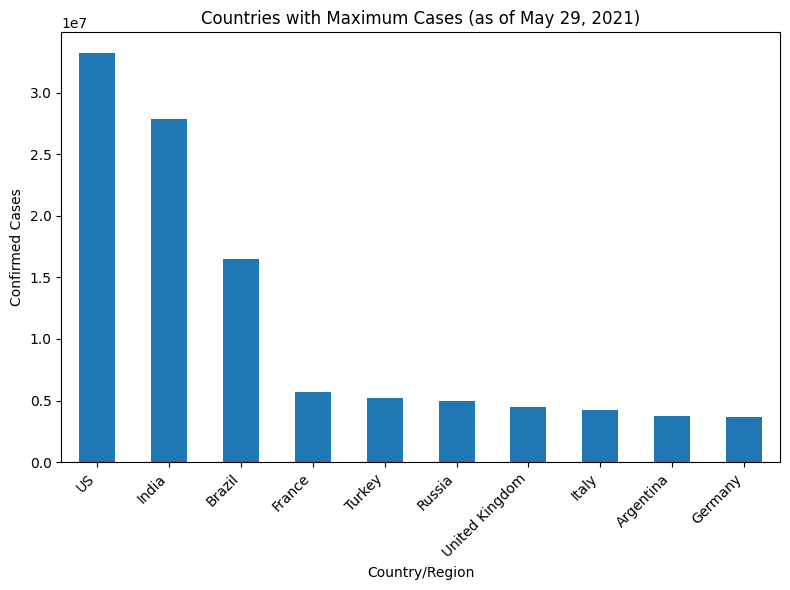

In [13]:
# Plot a bar chart showing the top 10 countries with the most COVID-19 cases.
# iloc[:10, -1] selects the first 10 rows and the last column (most recent date).
plt.figure(figsize=(8, 6))
df_confirmed_country.iloc[:10, -1].plot(kind='bar')
plt.title("Countries with Maximum Cases (as of May 29, 2021)")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 🇨🇳 Step 4: Province-Level Analysis (China)

In [14]:
# Filter rows where Country/Region is 'China'.
# Unlike single-row countries, China has province-level breakdown.
df_confirmed_china = df_confirmed.loc[df_confirmed['Country/Region'] == "China", :]

In [15]:
# Sort China's provinces by the latest date column in descending order
# so the province with the most cases appears first
df_confirmed_china = df_confirmed_china.sort_values(by="5/29/21", ascending=False)

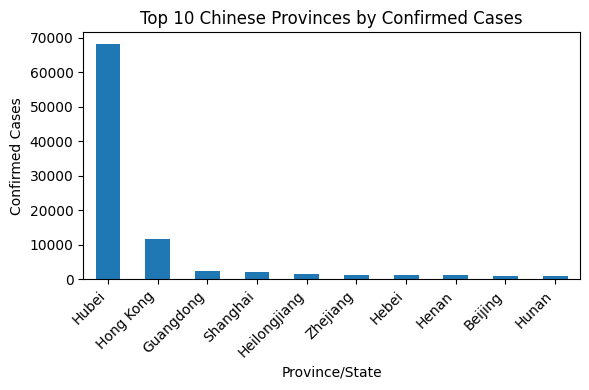

In [16]:
# Bar chart showing the top 10 Chinese provinces by confirmed cases.
# set_index('Province/State') makes province names appear on the x-axis.
# iloc[:10, -1] picks top 10 rows and the last (latest) date column.
plt.figure(figsize=(6, 4))
df_confirmed_china.set_index("Province/State").iloc[:10, -1].plot(kind='bar')
plt.title("Top 10 Chinese Provinces by Confirmed Cases")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 🧹 Step 5: Clean the Deaths Dataset

In [17]:
# Check how many missing values exist in each column of the deaths dataset.
# .sort_values(ascending=False) puts the columns with most nulls at the top.
df_deaths.isnull().sum().sort_values(ascending=False)

Province/State    190
Lat                 2
Long                2
4/20/20             1
4/29/21             0
                 ... 
1/31/20             0
2/1/20              0
2/2/20              0
2/3/20              0
5/29/21             0
Length: 498, dtype: int64

In [18]:
# Count how many columns belong to each data type.
# We expect mostly int64/float64 for date columns and object for string columns.
df_deaths.dtypes.value_counts()

int64      493
float64      3
object       2
Name: count, dtype: int64

In [19]:
# Show rows where Lat is null — these are usually aggregated/summary rows
# that don't correspond to a real geographic location
df_deaths.loc[df_deaths['Lat'].isnull(), :]

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
52,Repatriated Travellers,Canada,NaN,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88,Unknown,China,NaN,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
# How many rows does China have in the deaths dataset?
# (Checking before we drop null Lat/Long rows)
df_deaths[df_deaths['Country/Region'] == 'China'].shape

(34, 498)

In [21]:
# Drop all rows where Lat OR Long is missing.
# These rows can't be properly joined with the other datasets.
# axis=0 means drop rows (not columns), inplace=True modifies df_deaths directly.
df_deaths.dropna(subset=['Lat', 'Long'], axis=0, inplace=True)

In [22]:
# Imputing missing date values for Algeria using backward fill (bfill).
# bfill(axis=1) fills NaN cells in a row with the NEXT column's value
# (i.e., fills missing date with the next date's value — a reasonable estimate).
df_deaths.loc[df_deaths['Country/Region'] == 'Algeria'] = (
    df_deaths.loc[df_deaths['Country/Region'] == 'Algeria'].bfill(axis=1)
)

C:\Users\sachi\AppData\Local\Temp\ipykernel_21800\3618436652.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[28.0339]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_deaths.loc[df_deaths['Country/Region'] == 'Algeria'] = (
C:\Users\sachi\AppData\Local\Temp\ipykernel_21800\3618436652.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.6596]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_deaths.loc[df_deaths['Country/Region'] == 'Algeria'] = (
C:\Users\sachi\AppData\Local\Temp\ipykernel_21800\3618436652.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0]' has dtype incompatible with int64, please explicitly cast to a compatible dtype firs

In [23]:
# Fill missing Province/State values with the string 'All Provinces'.
# Countries that don't have province-level data will have NaN here;
# we replace NaN with a meaningful label so we can join datasets properly.
df_deaths['Province/State'].fillna("All Provinces", inplace=True)
df_confirmed['Province/State'].fillna("All Provinces", inplace=True)
df_recovery['Province/State'].fillna("All Provinces", inplace=True)

C:\Users\sachi\AppData\Local\Temp\ipykernel_21800\2432514669.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_deaths['Province/State'].fillna("All Provinces", inplace=True)
C:\Users\sachi\AppData\Local\Temp\ipykernel_21800\2432514669.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

---
## 🇮🇳 Step 6: India — Daily Cases & Recovery Rate

In [24]:
# Filter the confirmed dataset to just India's row.
# India has no province-level breakdown, so it's a single row.
df_india_raw = df_confirmed.loc[df_confirmed['Country/Region'] == "India", :]

In [25]:
# Transpose the data so that dates become the row index.
# iloc[:, 4:] skips the first 4 metadata columns (Province/State, Country/Region, Lat, Long)
# .T flips rows and columns, making each date a row.
df_india_ts = df_india_raw.iloc[:, 4:].T

In [26]:
# Rename the single column to 'Cumulative Cases' for clarity
df_india_ts.columns = ["Cumulative Cases"]

In [27]:
# Calculate daily NEW cases by computing the difference between consecutive days.
# .diff() subtracts the previous row's value from the current row.
# The first row will be NaN because there's no previous day to subtract from.
df_india_ts['Daily Cases'] = df_india_ts['Cumulative Cases'].diff()

In [28]:
# View the last 5 rows to see recent daily case numbers
df_india_ts.tail()

,Cumulative Cases,Daily Cases
5/25/21,27157795,208921.0
5/26/21,27369093,211298.0
5/27/21,27555457,186364.0
5/28/21,27729247,173790.0
5/29/21,27894800,165553.0


In [29]:
# Find the date when India recorded its HIGHEST single-day new cases.
# idxmax() returns the index label (date) of the maximum value.
highest_cases_date = df_india_ts['Daily Cases'].idxmax()
print("Date of highest daily cases in India:", highest_cases_date)
print("Cases on that day:", df_india_ts.loc[highest_cases_date, 'Daily Cases'])

Date of highest daily cases in India: 5/6/21
Cases on that day: 414188.0


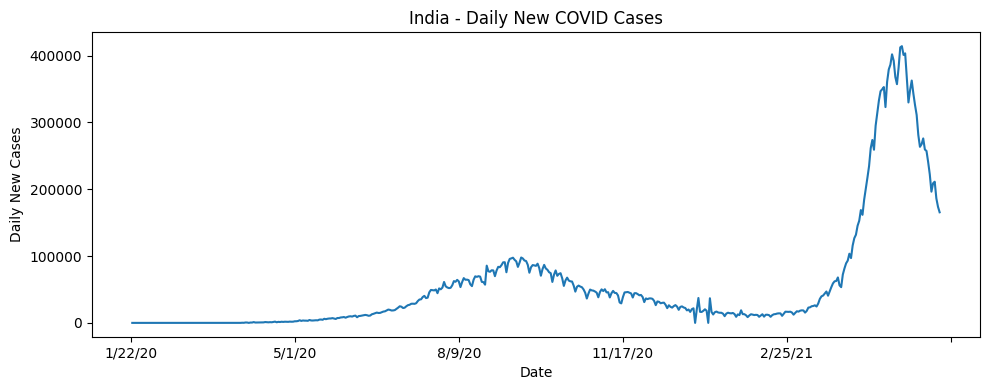

In [30]:
# Line chart showing India's daily new COVID-19 cases over time.
# The wave peaks are clearly visible — especially the second wave in early 2021.
df_india_ts['Daily Cases'].plot(kind='line', figsize=(10, 4), title="India - Daily New COVID Cases")
plt.xlabel("Date")
plt.ylabel("Daily New Cases")
plt.tight_layout()
plt.show()

In [31]:
# Calculate India's daily recovery RATE = Recoveries / Total Confirmed Cases.
# We transpose the recovery CSV for India to get a time-series format.
# A small epsilon (0.00000001) is added to the denominator to avoid division by zero.

df_total_india    = df_confirmed.loc[df_confirmed['Country/Region'] == "India", '1/22/20':].T
df_recovery_india = df_recovery.loc[df_recovery['Country/Region']  == "India", '1/22/20':].T

df_total_india.columns    = ["Total Cases"]
df_recovery_india.columns = ["Total Recoveries"]

# Recovery rate ranges from 0 (0%) to 1 (100%)
df_recovery_rate = df_recovery_india['Total Recoveries'] / (df_total_india['Total Cases'] + 0.00000001)

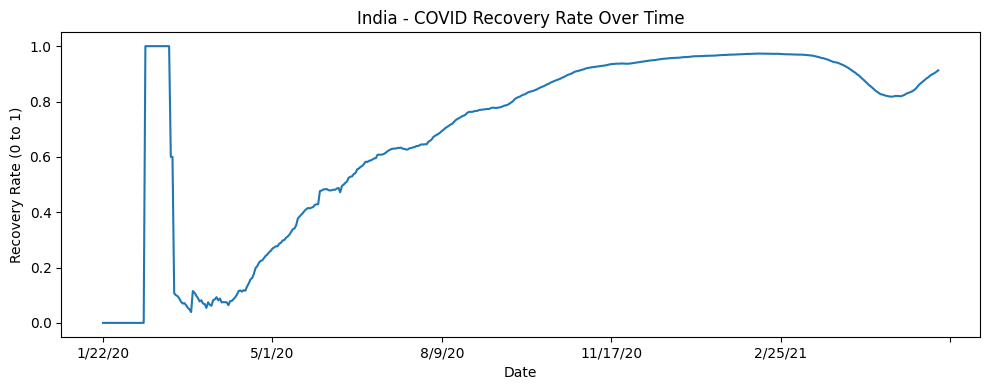

In [32]:
# Plot India's recovery rate over time.
# A rising curve means more of the confirmed cases have eventually recovered.
df_recovery_rate.plot(kind='line', figsize=(10, 4), title="India - COVID Recovery Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Recovery Rate (0 to 1)")
plt.tight_layout()
plt.show()

---
## 🔄 Step 7: Reshape Data — Wide to Long (Melt)

In [33]:
# Confirm that all three datasets have the same column structure
print(df_confirmed.columns.tolist()[:8], "...")

['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20'] ...


In [34]:
# MELT: Convert the wide-format DataFrame (one column per date)
# into a long-format DataFrame (one row per date per country).
# id_vars = columns to keep as-is (identifiers)
# var_name = name for the new 'date' column
# value_name = name for the values being unpacked
df_confirmed_melt = df_confirmed.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    var_name="Date",
    value_name="Confirmed Cases"
)

In [35]:
# Melt recovery data the same way
df_recovery_melt = df_recovery.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    var_name="Date",
    value_name="Recovered Cases"
)

In [36]:
# Melt deaths data the same way
df_death_melt = df_deaths.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    var_name="Date",
    value_name="Death Cases"
)

In [37]:
# Check the shapes after melting.
# Confirmed and Deaths: 276 countries/provinces × 494 dates = ~136,000 rows
# Recovery: 261 entries × 494 dates = ~128,000 rows
print("Confirmed melt:", df_confirmed_melt.shape)
print("Recovery melt: ", df_recovery_melt.shape)
print("Deaths melt:   ", df_death_melt.shape)

Confirmed melt: (136344, 6)
Recovery melt:  (128934, 6)
Deaths melt:    (135356, 6)


In [38]:
# Verify column names of each melted DataFrame
print(df_confirmed_melt.columns.tolist())
print(df_recovery_melt.columns.tolist())
print(df_death_melt.columns.tolist())

['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed Cases']
['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Recovered Cases']
['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Death Cases']


---
## 🔗 Step 8: Merge All Three Datasets

In [39]:
# First merge: Join confirmed cases with recovered cases.
# We use an INNER join — only keep rows that exist in BOTH DataFrames.
# The join keys are the 5 identifier columns (Province/State, Country/Region, Lat, Long, Date).
# Because all 3 CSVs come from the same source and have matching Lat/Long values,
# the inner join will work correctly and retain most rows.
df_merged = pd.merge(
    df_confirmed_melt,
    df_recovery_melt,
    on=["Province/State", "Country/Region", "Lat", "Long", "Date"],
    how="inner"
)
print("After first merge shape:", df_merged.shape)

After first merge shape: (125970, 7)


In [40]:
# Second merge: Join the above result with deaths data.
# Same inner join logic — only keep rows that match across all three datasets.
df_merged = pd.merge(
    df_merged,
    df_death_melt,
    on=["Province/State", "Country/Region", "Lat", "Long", "Date"],
    how="inner"
)
print("After second merge shape:", df_merged.shape)

After second merge shape: (124982, 8)


In [41]:
# Convert the 'Date' column from string format (e.g., '1/22/20')
# to proper Python datetime objects for time-series operations.
# format="%m/%d/%y" tells pandas the string's date structure:
#   %m = month, %d = day, %y = 2-digit year
df_merged['Date'] = pd.to_datetime(df_merged['Date'], format="%m/%d/%y")

In [42]:
# View the first 5 rows of the final merged DataFrame.
# It should now have 8 columns:
# Province/State, Country/Region, Lat, Long, Date, Confirmed Cases, Recovered Cases, Death Cases
df_merged.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed Cases,Recovered Cases,Death Cases
0,All Provinces,Afghanistan,33.93911,67.709953,2020-01-22,0,0.0,0
1,All Provinces,Albania,41.1533,20.1683,2020-01-22,0,0.0,0
2,All Provinces,Andorra,42.5063,1.5218,2020-01-22,0,0.0,0
3,All Provinces,Angola,-11.2027,17.8739,2020-01-22,0,0.0,0
4,All Provinces,Antigua and Barbuda,17.0608,-61.7964,2020-01-22,0,0.0,0


In [43]:
# Add a 'month-year' column to help group data by month later.
# .dt.strftime("%m-%Y") formats the datetime as 'MM-YYYY' (e.g., '01-2020', '05-2021')
df_merged['month-year'] = df_merged['Date'].dt.strftime("%m-%Y")
print("Merged DataFrame shape (with month-year):", df_merged.shape)

Merged DataFrame shape (with month-year): (124982, 9)


---
## 🇮🇳 Step 9: India — Daily Cases & Monthly Analysis (from Merged Data)

In [44]:
# Filter the merged DataFrame for India.
# We use .copy() to avoid SettingWithCopyWarning when adding new columns later.
df_india = df_merged.loc[df_merged['Country/Region'] == "India", :].copy()

In [45]:
# Preview India's data — now each row is one day in India's COVID timeline
df_india.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed Cases,Recovered Cases,Death Cases,month-year
127,All Provinces,India,20.593684,78.96288,2020-01-22,0,0.0,0,01-2020
380,All Provinces,India,20.593684,78.96288,2020-01-23,0,0.0,0,01-2020
633,All Provinces,India,20.593684,78.96288,2020-01-24,0,0.0,0,01-2020
886,All Provinces,India,20.593684,78.96288,2020-01-25,0,0.0,0,01-2020
1139,All Provinces,India,20.593684,78.96288,2020-01-26,0,0.0,0,01-2020


In [46]:
# Calculate India's daily NEW confirmed cases.
# .diff() gives the difference from the previous row (previous day's cumulative count).
# The first row will be NaN since there's no prior day.
df_india['Daily Confirmed Cases'] = df_india['Confirmed Cases'].diff()

In [47]:
# Confirm the new column exists and looks correct
df_india.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed Cases,Recovered Cases,Death Cases,month-year,Daily Confirmed Cases
127,All Provinces,India,20.593684,78.96288,2020-01-22,0,0.0,0,01-2020,NaN
380,All Provinces,India,20.593684,78.96288,2020-01-23,0,0.0,0,01-2020,0.0
633,All Provinces,India,20.593684,78.96288,2020-01-24,0,0.0,0,01-2020,0.0
886,All Provinces,India,20.593684,78.96288,2020-01-25,0,0.0,0,01-2020,0.0
1139,All Provinces,India,20.593684,78.96288,2020-01-26,0,0.0,0,01-2020,0.0


In [48]:
# Group India's data by 'month-year' and find the MAX daily confirmed cases
# in each month. This helps identify which month had the worst single-day surge.
df_max_monthly_cases = df_india.groupby('month-year')['Daily Confirmed Cases'].max()
df_max_monthly_cases

month-year
01-2020         1.0
01-2021     37256.0
02-2020         1.0
02-2021     16752.0
03-2020       227.0
03-2021     72330.0
04-2020      1893.0
04-2021    401993.0
05-2020      8782.0
05-2021    414188.0
06-2020     19906.0
07-2020     61242.0
08-2020     85687.0
09-2020     97894.0
10-2020     81484.0
11-2020     50356.0
12-2020     36652.0
Name: Daily Confirmed Cases, dtype: float64

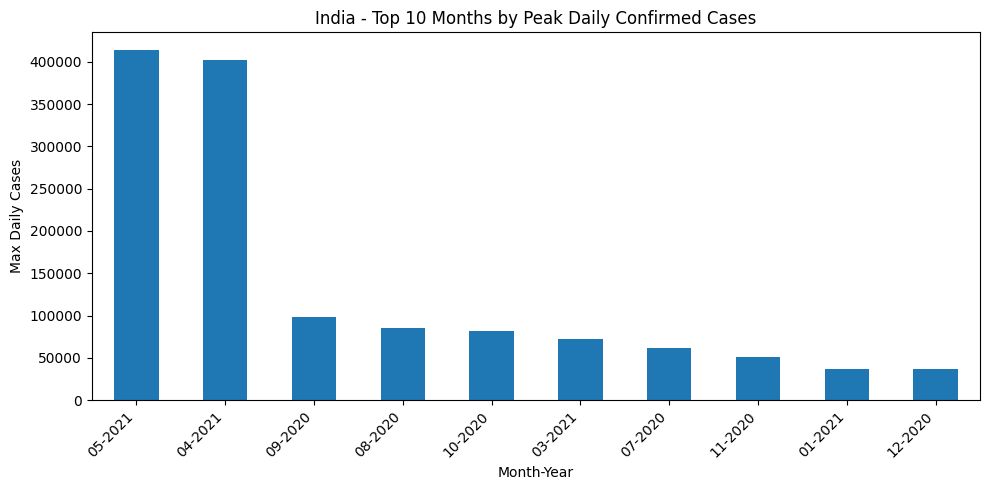

In [49]:
# Bar chart showing the top 10 worst months in India by peak daily cases.
# sort_values(ascending=False)[:10] gets the top 10 months.
df_max_monthly_cases.sort_values(ascending=False)[:10].plot(kind="bar", figsize=(10, 5))
plt.title("India - Top 10 Months by Peak Daily Confirmed Cases")
plt.xlabel("Month-Year")
plt.ylabel("Max Daily Cases")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 🇺🇸 Step 10: India vs USA — Daily Cases Comparison

In [50]:
# Filter the merged DataFrame for the USA.
# In this dataset, the USA is labeled as 'US' (not 'United States').
# .copy() prevents SettingWithCopyWarning when we add the daily cases column.
df_usa = df_merged.loc[df_merged['Country/Region'] == "US", :].copy()

In [51]:
# Compute USA's daily new confirmed cases the same way as India
df_usa['Daily Confirmed Cases'] = df_usa['Confirmed Cases'].diff()

<Figure size 1200x500 with 0 Axes>

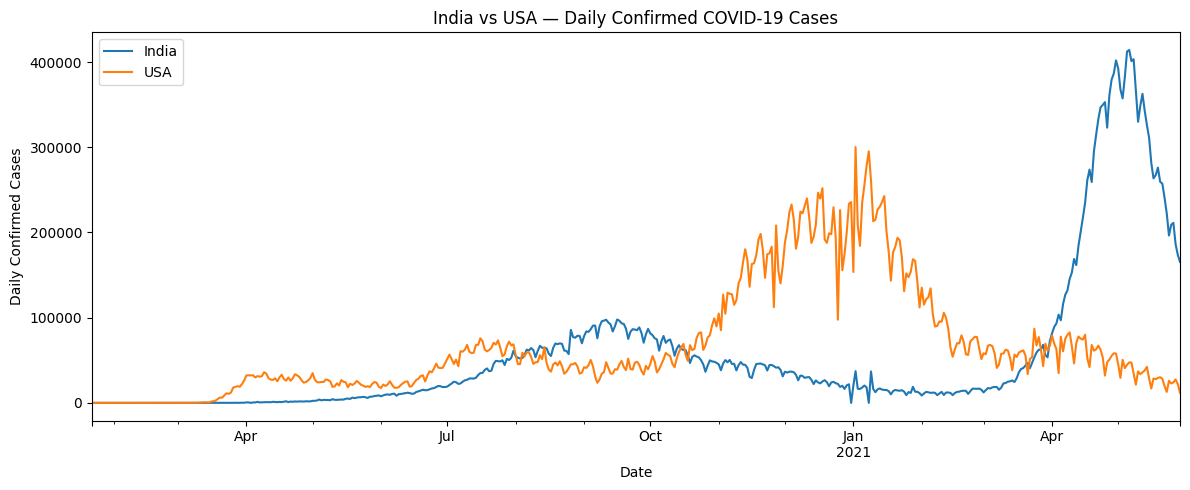

In [52]:
# Line chart comparing India vs USA daily confirmed cases over time.
# We plot on the same axes (ax=plot) so both lines appear on the same graph.
# This makes it easy to visually compare the two countries' waves.
plt.figure(figsize=(12, 5))
plot = df_india.plot(
    kind='line', x="Date", y="Daily Confirmed Cases",
    label="India", figsize=(12, 5)
)
plot = df_usa.plot(
    kind='line', x="Date", y="Daily Confirmed Cases",
    label="USA", ax=plot
)
plt.title("India vs USA — Daily Confirmed COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Daily Confirmed Cases")
plt.legend()
plt.tight_layout()
plt.show()